In [2]:
# Your imports HERE !!!!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


01 — 1.5 pt (Matplotlib + Seaborn: scatter + regresión)

Enunciado

Dado el siguiente DataFrame, crea:

Un scatter plot de X vs Y coloreado por Grupo.

Una línea de regresión para cada grupo (una recta por grupo).

Añade título, ejes y rejilla. Tamaño de figura: (9, 4).

In [3]:
df = pd.DataFrame({
    "X": [1,2,3,4,5, 1,2,3,4,5],
    "Y": [1.2,2.1,2.9,4.2,5.1, 2.1,2.2,3.4,3.8,4.2],
    "Grupo": ["A"]*5 + ["B"]*5
})

C:\Users\Acer Predator\AppData\Local\Temp\ipykernel_11448\1080977723.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


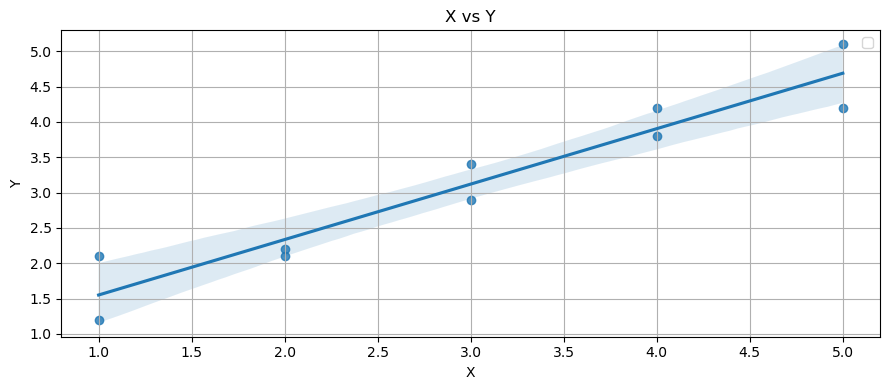

In [20]:
# Paso 1. Crear figura y varios ejes
fig, axs = plt.subplots(figsize=(9, 4))
# 2. Dibujar datos en cada eje
 

axs= sns.regplot(x="X", y="Y", data=df)

# s= tamaño del punto
# linewidth = tamaño del borde del punto
# edgecolor = color del borde del punto
# label para la leyenda , solo en Matplotlib
# 3. Configurar cada eje

axs.set_title("X vs Y")
axs.set_xlabel("X")
axs.set_ylabel("Y")


# Paso 5: ajustes globales
plt.tight_layout() # Evita solapamientos

# Paso 6: elementos auxiliares
axs.legend()
axs.grid(True)
# Paso 7: mostrar el gráfico
plt.show()


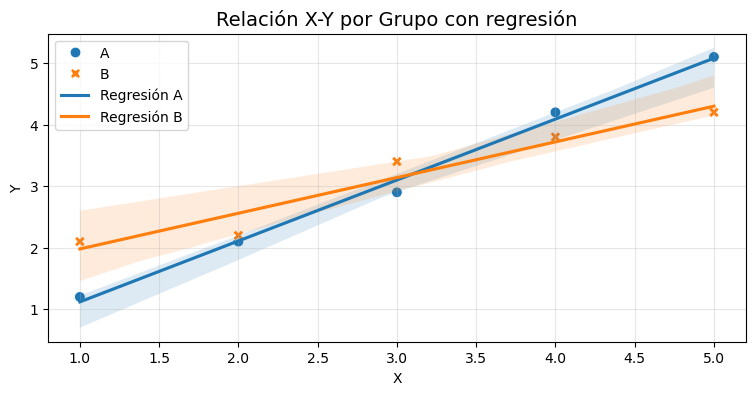

In [16]:
plt.figure(figsize=(9, 4))

# scatter por grupo
sns.scatterplot(data=df, x="X", y="Y", hue="Grupo", style="Grupo", s=60)

# regresión por grupo (una recta por grupo)
for g, sub in df.groupby("Grupo"):
    sns.regplot(
        data=sub, x="X", y="Y",
        scatter=False,  # ya pintado
        label=f"Regresión {g}"
    )

plt.title("Relación X-Y por Grupo con regresión", fontsize=14)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


02 — 1.5 pt (Pandas: función de ingeniería + filtro + orden)

Enunciado
Escribe una función build_score(df) que:

Seleccione solo columnas numéricas.

Cree una columna Score = media fila a fila de las numéricas.

Filtre filas con Score estrictamente mayor que el percentil 60 de Score.

Ordene por Score descendentemente y resetea índice.

Incluye el test con assert.

In [22]:
source_dataframe = pd.DataFrame({
    "A": [1, 20, 3, 10, 2],
    "B": [2, 10, 4, 10, 3],
    "C": [3, 0, 5, 10, 4],
    "Tag": list("abcde")
})
display(source_dataframe)

,A,B,C,Tag
0,1,2,3,a
1,20,10,0,b
2,3,4,5,c
3,10,10,10,d
4,2,3,4,e


In [35]:
def build_score(df): 
    source_dataframe["Score"]=source_dataframe.select_dtypes(include="number").sum(axis=1)
    cuartil=source_dataframe['Score'].quantile(0.6)
    print(cuartil)
    df_filtrado= source_dataframe[source_dataframe["Score"]>cuartil].sort_values(by="Score", ascending=False)
    return df_filtrado

In [36]:
build_score(source_dataframe)

76.8


,A,B,C,Tag,Score
1,20,10,0,b,120.0
3,10,10,10,d,120.0


In [37]:
# Test Use Case
output = build_score(source_dataframe)

# Comprobaciones robustas (no dependemos de “valores exactos” de percentil a mano)
assert "Score" in output.columns
assert output["Score"].is_monotonic_decreasing
assert (output["Score"] > np.percentile(source_dataframe[["A","B","C"]].mean(axis=1), 60)).all()

output

96.0


,A,B,C,Tag,Score
1,20,10,0,b,150.0
3,10,10,10,d,150.0


03 — 1.5 pt (Plain Python: generador “streaming”)

Enunciado

Escribe un generador running_mean() que, en cada iteración, devuelva la media acumulada de los enteros 1,2,3,... indefinidamente.

Ejemplo: salidas esperadas para las primeras 8 llamadas:

[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]

In [47]:
def running_mean(): 
    n=1
    suma=0
    while True:
        for numeros in range(n+1):
            suma+=numeros
        yield suma/n
        n+=1
        suma=0

In [54]:
# Test Use Case
expected_output = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
g = running_mean()
output = [next(g) for _ in range(len(expected_output))]

display(expected_output)
display(output)
assert np.allclose(output, expected_output)

[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]

[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]

04 — 1.5 pt (NumPy/Pandas: máscara avanzada + primos + NaN + limpieza)

Enunciado

Crea una función transform_matrix(M) que reciba una matriz NumPy M y:

Reemplace números primos positivos por sqrt(n) redondeado a 2 decimales.

Reemplace múltiplos negativos de 4 por NaN.

Elimine las filas que contengan 2 o más NaN.

Devuelva el resultado como np.ndarray de float.

Usa el test.

In [116]:
source = np.array([
    [  2,  -8,  15,  17],
    [  4, -12,   9,  10],
    [ 19,  -4,  21,  22],
    [ 23,   5,  -8, -16],
])
source= source.astype(np.float32)
source
df= pd.DataFrame(source)
source

array([[  2.,  -8.,  15.,  17.],
       [  4., -12.,   9.,  10.],
       [ 19.,  -4.,  21.,  22.],
       [ 23.,   5.,  -8., -16.]], dtype=float32)

In [117]:
# Función que determina si un número es primo 
def is_prime(n): 
    for intermedios in range(1, int(n)): 
        if n%intermedios==0: 
            return False
    return True




def transform_matrix(M):
    fila_ind=0 
    columna_ind=0
    
    # Cambia los primos positivos por sqrt 
    for fila in M:
        
        for valor in fila:
            if is_prime(valor)==True and valor>0:
                M[fila_ind, columna_ind]=np.sqrt(valor).round(2)
            
                
            if valor<0 and valor%4==0: 
                M[fila_ind, columna_ind]=np.nan  
            
                
            columna_ind+=1
        columna_ind=0 
            
        fila_ind+=1
        
    df= pd.DataFrame(M)
    tamaño=df.shape
    df.dropna(thresh=tamaño[0]-1, axis=0, inplace=True)
    return df

In [118]:
transform_matrix(source)

,0,1,2,3
0,2.0,NaN,15.0,17.0
1,4.0,NaN,9.0,10.0
2,19.0,NaN,21.0,22.0


In [119]:
# Test Use Case
output = transform_matrix(source)

# Validaciones clave
# - no debe haber filas con >=2 NaN
assert (np.isnan(output).sum(axis=1) < 2).all()
# - resultado float
assert output.dtype.kind == "f"

output

ValueError: cannot convert float NaN to integer